<a href="https://colab.research.google.com/github/miller00315/AI-For-Beginners/blob/main/exampl_rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introdução a Redes Neurais com TensorFlow e Keras**

Importação das bibliotecas, classes e métodos utilizados ao longo da aula:

In [1]:
import os
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay)
import matplotlib.pyplot as plt

Definição de uma semente aleatória fixa:

In [2]:
RANDOM_STATE = 7895

In [3]:
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

##**Carregando os dados**

Leitura do dataset a partir de um arquivo CSV armazenado em um repositório GitHub:

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/vqrca/ml-datasets/refs/heads/main/BankChurners_portugues.csv')

Exibição das primeiras observações para verificar a estrutura dos dados e as variáveis disponíveis:

In [5]:
df.head()

,Numero_Cliente,Target,Idade_Cliente,Genero,Numero_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda_Anual,Categoria_Cartao,Meses_Como_Cliente,...,Meses_Inativo_Ultimos_12_Meses,Contatos_Ultimos_12_Meses,Limite_Credito,Saldo_Rotativo_Total,Credito_Disponivel_Medio,Variacao_Valor_Transacoes_T4_T1,Valor_Total_Transacoes,Quantidade_Total_Transacoes,Variacao_Quantidade_Transacoes_T4_T1,Taxa_Media_Utilizacao_Credito
0,768805383,Ativo,45,Masculino,3,Ensino medio,Casado(a),US$ 60 mil a US$ 80 mil,Azul,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Ativo,49,Feminino,5,Graduacao,Solteiro(a),Menos de US$ 40 mil,Azul,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Ativo,51,Masculino,3,Graduacao,Casado(a),US$ 80 mil a US$ 120 mil,Azul,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Ativo,40,Feminino,4,Ensino medio,Nao informado,Menos de US$ 40 mil,Azul,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Ativo,40,Masculino,3,Sem escolaridade formal,Casado(a),US$ 60 mil a US$ 80 mil,Azul,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### **Preparando os dados para a rede neural**

Redes neurais **não interpretam valores categóricos**. Se codificássemos `Escolaridade` como 0, 1, 2, 3, a rede assumiria que existe uma **ordem e uma distância matemática** entre as categorias — o que raramente é verdade. Por isso, usamos o **`OneHotEncoder`**: cada categoria vira uma coluna binária independente (0 ou 1), sem impor qualquer relação artificial entre elas.

O alvo `Target` também é convertido para o formato numérico esperado pelo Keras: **0 para `Ativo` e 1 para `Inativo`**.

In [6]:
df_modelo = df.drop(columns=['Numero_Cliente'])

colunas_categoricas = [
    'Genero',
    'Escolaridade',
    'Estado_Civil',
    'Faixa_Renda_Anual',
    'Categoria_Cartao'
]

# Transforma variáveis categóricas em variáveis binárias
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[colunas_categoricas])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(colunas_categoricas))

# Mantém o dataframe original mas remove as colunas categóricas que foram codificadas
df_encoded = pd.concat([df.drop(columns=colunas_categoricas), encoded_df], axis=1)

X = df_encoded.drop('Target', axis=1)
y = (df_encoded['Target'] == 'Inativo').astype(int)

target_names = ['Ativo', 'Inativo']

Verificamos as dimensões finais dos dados após a codificação. O número de colunas de `X` agora é maior do que o original, pois cada variável categórica foi expandida em várias colunas binárias:

In [7]:
print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')

Formato de X: (10127, 38)
Formato de y: (10127,)


### **Separando treino e teste**

Assim como nos modelos anteriores, dividimos os dados em treino (80%) e teste (20%), mantendo a proporção original das classes com `stratify=y`:

In [8]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

### **Padronizando as variáveis numéricas**

Diferente das árvores, que são **insensíveis à escala** das variáveis, redes neurais são fortemente afetadas por variáveis em ordens de grandeza muito diferentes (por exemplo, idade em dezenas e valor de transação em milhares). Sem padronização, o gradiente descendente tem dificuldade em convergir e o treinamento se torna instável.

Aplicando a padronização. O `StandardScaler` aprende a escala usando apenas o treino e depois aplica a mesma transformação no teste:

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

Inspecionando rapidamente o resultado da padronização — os valores agora têm média próxima de zero e desvio padrão próximo de um:

In [11]:
X_treino_scaled

array([[ 1.93342791, -0.78208084, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.75259779,  1.33452938, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.59655062, -0.78208084,  1.2824446 , ..., -0.10419214,
        -0.04160737, -0.23821013],
       ...,
       [-0.63480958, -0.40856139, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.65938479,  1.58354234, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.80274183,  2.20607476, -1.81461419, ..., -0.10419214,
        -0.04160737, -0.23821013]])

In [12]:
X_teste_scaled

array([[-0.81636881,  0.21397102,  1.2824446 , ..., -0.10419214,
        -0.04160737, -0.23821013],
       [ 1.07772254, -0.15954843,  1.2824446 , ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.75448772,  0.21397102, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       ...,
       [-0.58121621, -1.1556003 ,  2.0567093 , ..., -0.10419214,
        -0.04160737,  4.19797433],
       [ 0.90705476, -1.03109381, -0.26608479, ..., -0.10419214,
        -0.04160737, -0.23821013],
       [-0.80173806, -0.15954843,  0.5081799 , ..., -0.10419214,
        -0.04160737, -0.23821013]])

### **Lidando com o desbalanceamento das classes**

Como existem menos clientes `Inativo`, vamos calcular pesos simples para as classes. Isso ajuda a rede a não ignorar a classe minoritária durante o treinamento:

In [13]:
from sklearn.utils.class_weight import compute_class_weight

In [14]:
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_treino
)

class_weight = {0: pesos[0], 1: pesos[1]}
class_weight

{0: np.float64(0.5957493749080747), 1: np.float64(3.1109831029185866)}

##**Montando uma rede neural simples**

A rede abaixo tem apenas uma camada intermediária pequena e uma saída para prever a probabilidade de churn. A saída será interpretada como:

* perto de 0: maior chance de cliente `Ativo`;
* perto de 1: maior chance de cliente `Inativo`.

In [15]:
modelo_rede = keras.Sequential([
    keras.layers.Input(shape=(X_treino_scaled.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

modelo_rede.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'recall',
        keras.metrics.AUC(name='auc')
    ]
)

modelo_rede.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

##**Treinando a rede**



In [16]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

historico = modelo_rede.fit(
    X_treino_scaled,
    y_treino,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight,
    verbose=1
)


Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6676 - loss: 0.6566 - recall: 0.6121 - val_auc: 0.8243 - val_loss: 0.5589 - val_recall: 0.7752
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8715 - loss: 0.4702 - recall: 0.8276 - val_auc: 0.8832 - val_loss: 0.4661 - val_recall: 0.8256
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8971 - loss: 0.4135 - recall: 0.8314 - val_auc: 0.9000 - val_loss: 0.4211 - val_recall: 0.8295
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9092 - loss: 0.3861 - recall: 0.8381 - val_auc: 0.9104 - val_loss: 0.3947 - val_recall: 0.8411
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9178 - loss: 0.3672 - recall: 0.8458 - val_auc: 0.9182 - val_loss: 0.3758 - val_recall: 0.8488
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9248 - loss: 0.3519 - recall: 0.8487 - val_auc: 0.9242 - val_loss: 0.3611 - val_recall: 0.8450
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.930

Visualizando a evolução da rede ao longo do treinamento. A ideia é observar se o desempenho no treino e na validação caminham de forma parecida:

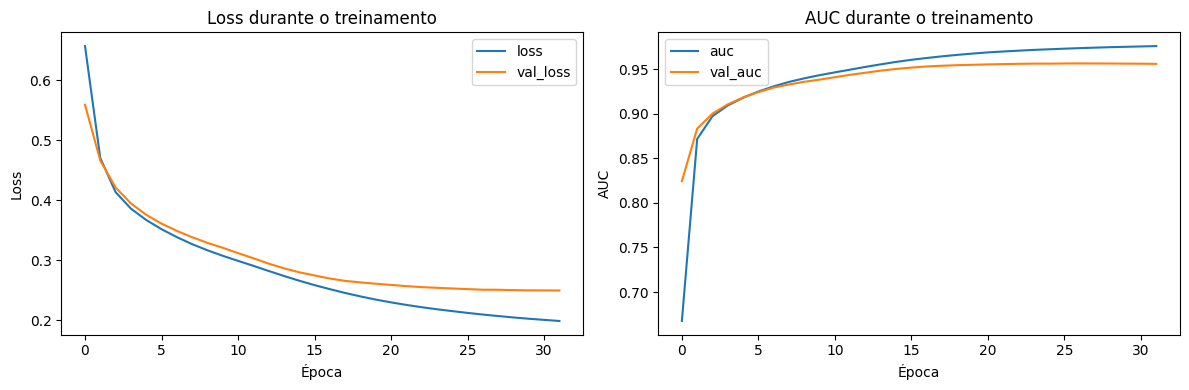

In [17]:
historico_df = pd.DataFrame(historico.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

historico_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('Loss durante o treinamento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')

historico_df[['auc', 'val_auc']].plot(ax=axes[1])
axes[1].set_title('AUC durante o treinamento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')

plt.tight_layout()
plt.show()

##**Avaliando no conjunto de teste**
Agora vamos avaliar a rede em dados que ela não viu durante o treinamento. Como a rede retorna probabilidades, usamos o ponto de corte de 0,5 para transformar a probabilidade em classe prevista:

In [18]:
probabilidades_teste = modelo_rede.predict(X_teste_scaled).ravel()
predicoes_teste = (probabilidades_teste >= 0.5).astype(int)

acuracia_teste = accuracy_score(y_teste, predicoes_teste)
roc_auc_teste = roc_auc_score(y_teste, probabilidades_teste)

print(f'Acurácia em teste: {acuracia_teste:.3f}')
print(f'ROC-AUC em teste:  {roc_auc_teste:.3f}')
print()
print('Relatório de classificação:')
print(classification_report(
    y_teste,
    predicoes_teste,
    target_names=target_names,
    digits=3,
    zero_division=0
))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Acurácia em teste: 0.899
ROC-AUC em teste:  0.955

Relatório de classificação:
              precision    recall  f1-score   support

       Ativo      0.972     0.906     0.938      1701
     Inativo      0.636     0.862     0.732       325

    accuracy                          0.899      2026
   macro avg      0.804     0.884     0.835      2026
weighted avg      0.918     0.899     0.905      2026



Matriz de confusão normalizada para observar os acertos e erros em cada classe:

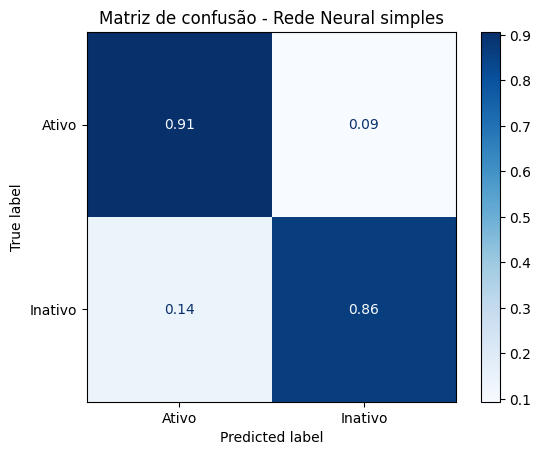

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    predicoes_teste,
    display_labels=target_names,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)
plt.title('Matriz de confusão - Rede Neural simples')
plt.show()

Curva ROC para avaliar a capacidade da rede de separar clientes ativos e inativos:

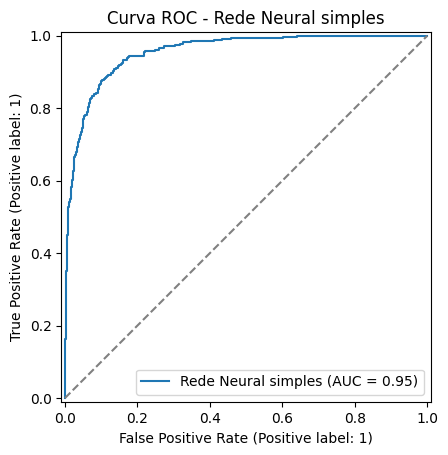

In [20]:
RocCurveDisplay.from_predictions(
    y_teste,
    probabilidades_teste,
    name='Rede Neural simples'
)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curva ROC - Rede Neural simples')
plt.show()